## Deterministic Synthetic Dataset

This implementation guarantees:

- Fully deterministic dataset
- Fully controlled randomness
- True convergence check
- Handles empty clusters
- Multiple initialization strategies
- Selection of k via inter-cluster variance
- Direct sklearn validation
- Fully reproducible experiments

### Distance and Centroid Computation

The Euclidean distance is used to measure similarity between a data point and a centroid:

$$
d(p,q) = \sqrt{\sum_{i=1}^{n}(p_i - q_i)^2}
$$

The centroid of a cluster is computed as the mean of all points in that cluster:

$$
\mu_j = \frac{1}{n_j}\sum_{x_i \in C_j} x_i
$$

These two formulas correspond to the `euclidean()` and `mean()` functions implemented in the code.

### Between-Cluster Sum of Squares (BSS)

The inter-cluster variance is computed using the Between-Cluster Sum of Squares:

$$
BSS = \sum_{j=1}^{k} n_j \, ||\mu_j - \mu||^2
$$

Where:
- $k$ = number of clusters  
- $n_j$ = number of points in cluster $j$  
- $\mu_j$ = centroid of cluster $j$  
- $\mu$ = overall mean of the dataset  

In [ ]:
# Import required libraries
import random
import math
from copy import deepcopy
import matplotlib.pyplot as plt

# Random seed values for reproducibility
rnd_seed = 1000
default_seed = 2000

random.seed(rnd_seed)

In [ ]:
# Generate a synthetic dataset with three clusters
def generate_dataset(seed=default_seed, n_per_cluster=300):
    random.seed(seed)

      # Predefined cluster centers
    centers = [(2, 2), (8, 3), (3, 6)]
    data = []

    for cx, cy in centers:
        for _ in range(n_per_cluster):
            x = random.gauss(cx, 0.6)
            y = random.gauss(cy, 0.6)
            data.append([x, y])

    return data

##  Python K-Means Implementation

In [ ]:
# Compute the Euclidean distance between two points
def euclidean(p1, p2):
    return math.sqrt(sum((a - b) ** 2 for a, b in zip(p1, p2)))


# Compute the centroid (mean point) of a cluster
def mean(points):
    dim = len(points[0])

    # Compute the average of each coordinate across all points in the cluster
    return [
        sum(p[i] for p in points) / len(points)
        for i in range(dim)
    ]

Initialization Methods

In [ ]:
# Initialize centroids for the K-Means algorithm
def initialize_centroids(data, k, method="random", seed=default_seed):
    random.seed(seed)

    if method == "random":
        return random.sample(data, k)

    elif method == "kmeans++":
        centroids = [random.choice(data)]

        for _ in range(1, k):
            distances = []

             # Compute squared distance from each point to the nearest centroid
            for point in data:
                min_dist = min(euclidean(point, c)**2 for c in centroids)
                distances.append(min_dist)



            total = sum(distances)
            probs = [d / total for d in distances]

            # Select a new centroid using weighted probability
            r = random.random()
            cumulative = 0
            for i, p in enumerate(probs):
                cumulative += p
                if r < cumulative:
                    centroids.append(data[i])
                    break

        return centroids

    else:
        raise ValueError("Unknown initialization method")

Core K-Means Algorithm

In [ ]:
# Implementation of the K-Means clustering algorithm
def kmeans(
    data,
    k,
    init="random",
    seed=rnd_seed,
    max_iter=100,
    tol=1e-4,
    verbose=False
):

     # Initialize centroids using the chosen initialization method
    centroids = initialize_centroids(data, k, method=init, seed=rnd_seed)


 # Repeat the clustering process until convergence or maximum iterations
    for iteration in range(max_iter):
        clusters = [[] for _ in range(k)]

        # Assignment step:assign each point to the nearest centroid
        for point in data:
            distances = [euclidean(point, c) for c in centroids]
            idx = distances.index(min(distances))
            clusters[idx].append(point)

    # Save the previous centroids to check for convergence later
        old_centroids = deepcopy(centroids)

        # Update step:recompute centroids as the mean of cluster points
        for i in range(k):
            if clusters[i]:  # Avoid empty cluster
                centroids[i] = mean(clusters[i])
            else:
                centroids[i] = random.choice(data)

        # Convergence check
        shift = sum(euclidean(old_centroids[i], centroids[i]) for i in range(k))

        if verbose:
            print(f"Iteration {iteration}, shift={shift}")

        if shift < tol:
            break

    # Return the final centroids and the clusters of data points
    return centroids, clusters

## Inter-Cluster Variance (Between Cluster Sum of Squares)

This helps choose optimal k.

In [ ]:
# Calculate the Between-Cluster Sum of Squares (BSS) to measure cluster separation
def inter_cluster_variance(data, clusters, centroids):
    overall_mean = mean(data)


    # Compute the overall mean of all data points
    bss = 0
    for i, cluster in enumerate(clusters):
        n = len(cluster)
        if n > 0:
            dist = euclidean(centroids[i], overall_mean)


            # Add weighted squared distance to BSS
            bss += n * dist**2

    return bss

## Automatic Selection of k Using Inter-Cluster Variance

In [ ]:
# Evaluate different cluster counts (k) by running K-Means and computing inter-cluster variance for each k
def evaluate_k(data, k_values, init="kmeans++", seed=default_seed):
    scores = {}

    for k in k_values:
        centroids, clusters = kmeans(data, k, init=init, seed=seed)
        score = inter_cluster_variance(data, clusters, centroids)
        scores[k] = score

    return scores

Usage:

In [ ]:
# Generate the dataset, evaluate clustering performance for different k values, and print the inter-cluster variance scores
data = generate_dataset()

scores = evaluate_k(data, k_values=[2,3,4,5])
print(scores)

{2: 6114.706583408291, 3: 8708.61513670599, 4: 8775.879167664965, 5: 8817.691130408946}


## Comparison with sklearn

In [ ]:
from sklearn.cluster import KMeans
import numpy as np

data = generate_dataset()
X = np.array(data)

# Our implementation
centroids_py, clusters_py = kmeans(data, k=3, init="kmeans++", seed=rnd_seed)

# Sklearn implementation
kmeans_sklearn = KMeans(
    n_clusters=3,
    init="k-means++",
    random_state=rnd_seed,
    n_init=10
)
kmeans_sklearn.fit(X)

print("Python centroids:")
print(centroids_py)

print("\nSklearn centroids:")
print(kmeans_sklearn.cluster_centers_)

Python centroids:
[[3.0043576225627233, 6.000957471536425], [7.9545575353045175, 3.0205250787745466], [2.01438701694208, 1.96206134899769]]

Sklearn centroids:
[[7.95455754 3.02052508]
 [2.01438702 1.96206135]
 [3.00435762 6.00095747]]


## Analysis
### Elbow Method

In [ ]:
# Compute inertia (within-cluster sum of squares) for different k values to evaluate clustering compactness
def compute_inertia(data, k_values, init="kmeans++", seed=default_seed):
    inertia_values = []

    for k in k_values:
        centroids, clusters = kmeans(
            data, k,
            init=init,
            seed=seed
        )

        value = sum(
            euclidean(p, centroids[i])**2
            for i, cluster in enumerate(clusters)
            for p in cluster
        )


        inertia_values.append(value)

    return inertia_values

We normalize and detect the point with maximum distance from the straight line connecting first and last points.

This is a standard geometric elbow detection.

In [ ]:
# Detect the optimal number of clusters using the Elbow Method
def detect_elbow(k_values, inertia_values):

    # Normalize k and inertia
    k_norm = [(k - min(k_values)) / (max(k_values) - min(k_values)) for k in k_values]
    i_norm = [(i - min(inertia_values)) / (max(inertia_values) - min(inertia_values))
              for i in inertia_values]

    # Line between first and last point
    x1, y1 = k_norm[0], i_norm[0]
    x2, y2 = k_norm[-1], i_norm[-1]

    distances = []

    for x0, y0 in zip(k_norm, i_norm):

        # Distance from point to line
        numerator = abs((y2 - y1)*x0 - (x2 - x1)*y0 + x2*y1 - y2*x1)
        denominator = ((y2 - y1)**2 + (x2 - x1)**2)**0.5
        distances.append(numerator / denominator)

    elbow_index = distances.index(max(distances))
    return k_values[elbow_index]

In [ ]:
# Plot the elbow curve of inertia vs number of clusters and highlight the detected optimal k
def plot_elbow(k_values, inertia_values, optimal_k):
    plt.figure(figsize=(8, 6))
    plt.plot(k_values, inertia_values, marker="o")

    plt.axvline(optimal_k, color="red", linestyle="--",
                label=f"Detected Elbow (k={optimal_k})")

    plt.title("Elbow Method")
    plt.xlabel("Number of Clusters (k)")
    plt.ylabel("Inertia (WCSS)")
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
# Visualize K-Means clustering results by plotting data points for each cluster and marking the centroids
def plot_clusters(data, clusters, centroids, title="K-Means Clustering"):
    colors = [
        "red", "blue", "green", "purple", "orange",
        "cyan", "magenta", "brown", "pink", "gray"
    ]

    plt.figure(figsize=(8, 6))

     # Plot points belonging to each cluster
    for i, cluster in enumerate(clusters):
        xs = [p[0] for p in cluster]
        ys = [p[1] for p in cluster]
        plt.scatter(xs, ys, color=colors[i % len(colors)], alpha=0.6)

    #Plot cluster centroids as large black X markers
    cx = [c[0] for c in centroids]
    cy = [c[1] for c in centroids]
    plt.scatter(cx, cy, color="black", marker="X", s=200, label="Centroids")

    plt.title(title)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend()
    plt.grid(True)
    plt.show()

Detected optimal k: 3


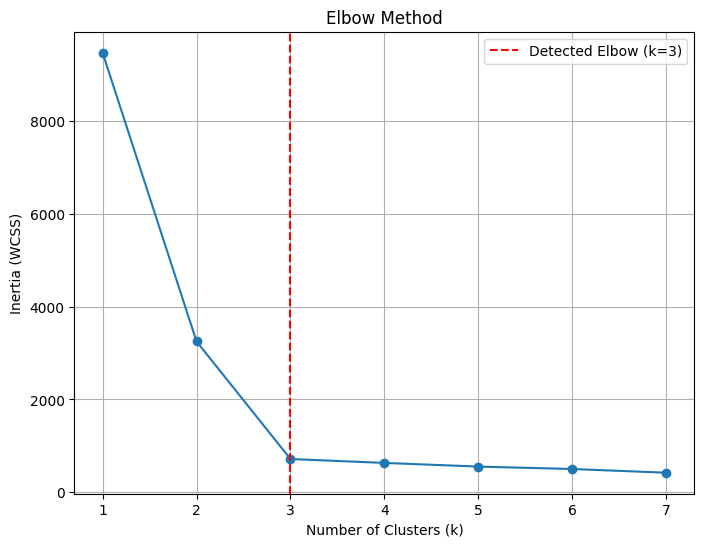

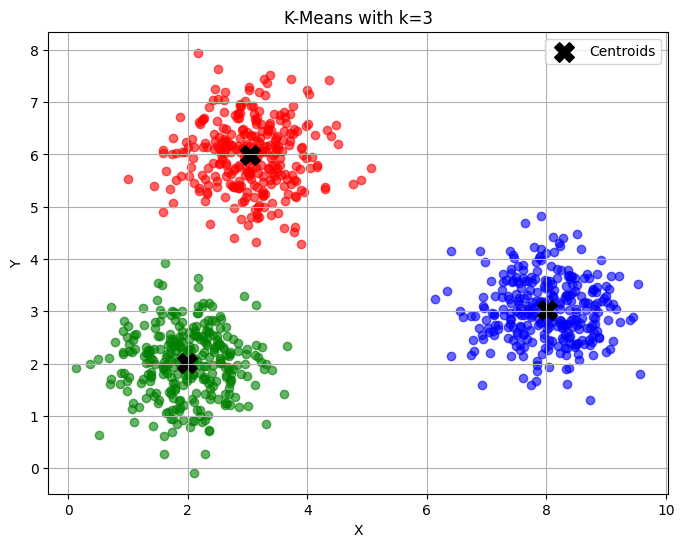

In [ ]:
# Generate data, compute inertia for different k values, detect the optimal number of clusters using the elbow method, run K-Means with that k, and visualize the results
data = generate_dataset(seed=rnd_seed)

k_values = list(range(1, 8))
inertia_values = compute_inertia(data, k_values)

optimal_k = detect_elbow(k_values, inertia_values)

print("Detected optimal k:", optimal_k)

plot_elbow(k_values, inertia_values, optimal_k)

centroids, clusters = kmeans(data, k=optimal_k, init="kmeans++", seed=rnd_seed)

plot_clusters(data, clusters, centroids,
              title=f"K-Means with k={optimal_k}")